# Envelope + EMD demo

A small standalone look at one trial:

1. the amplitude envelope drawn over the audio waveform
2. the envelope change (signed), then its absolute value
3. IMF 1 and IMF 2 of the envelope
4. IMF 1 and IMF 2 of the envelope change

It loads one audio file and its matching `env_*.csv` (which already has the
`envelope` column), derives the change here, and runs EMD on both. Each step
prints the object it produced before plotting it.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile          # simple WAV reader, no extra install
import emd                            # empirical mode decomposition

## Pick one example (audio + its envelope)

By default this takes the first `.wav` in `AUDIO_DIR` and the `env_*.csv` whose
name contains the same stem. If the auto-match misses, set `AUDIO_FILE` and
`ENV_FILE` by hand.

In [2]:
AUDIO_DIR = '../../audios/103_203'      # folder of .wav files for this pair
ENV_DIR   = '../../TS_acoustics'        # folder of env_*.csv files

AUDIO_FILE = None                       # or a full path to one .wav
ENV_FILE   = None                       # or a full path to one env_*.csv

audio_path = AUDIO_FILE or sorted(glob.glob(os.path.join(AUDIO_DIR, '*.wav')))[0]
stem = os.path.splitext(os.path.basename(audio_path))[0]
if ENV_FILE:
    env_path = ENV_FILE
else:
    hits = sorted(glob.glob(os.path.join(ENV_DIR, f'env_{stem}*.csv')))
    assert hits, f"No env_*.csv matching stem '{stem}' in {ENV_DIR}. Set ENV_FILE by hand."
    env_path = hits[0]

print('audio file:', audio_path)
print('env file  :', env_path)

audio file: ../../audios/103_203\103_203_12_1_20250113_152455_doughnut_board.wav
env file  : ../../TS_acoustics\env_103_203_12_1_20250113_152455_doughnut_board.wav_norm.csv


In [3]:
# --- audio waveform ---
# scipy reads standard PCM WAV. If your files are 24-bit or mp3, use librosa
# instead:  wav, sr = librosa.load(audio_path, sr=None)
sr, data = wavfile.read(audio_path)
data = data.astype(float)
if data.ndim > 1:                        # stereo -> mono
    data = data.mean(axis=1)
peak = np.max(np.abs(data))
wav = data / peak if peak else data      # normalise to [-1, 1] for display
t_wav = np.arange(len(wav)) / sr
print('audio :', type(wav).__name__, '| shape', wav.shape, '| dtype', wav.dtype,
      '| sr', sr, 'Hz | duration', round(len(wav)/sr, 2), 's')

# --- envelope (already computed, in the env csv) ---
env = pd.read_csv(env_path)
print('\nenv csv:', env.shape, '| columns:', list(env.columns))
print(env.dtypes)

envelope = env['envelope'].to_numpy()
t_env = env['time'].to_numpy().astype(float)
if np.median(np.diff(t_env)) > 0.5:      # time looks like milliseconds -> seconds
    t_env = t_env / 1000.0
print('\nenvelope:', envelope.shape, envelope.dtype,
      '| range', round(float(envelope.min()), 4), 'to', round(float(envelope.max()), 4),
      '| ~', round(1 / np.median(np.diff(t_env))), 'Hz')
env.head()

audio : ndarray | shape (768000,) | dtype float64 | sr 44100 Hz | duration 17.41 s

env csv: (8708, 6) | columns: ['time', 'audio', 'envelope', 'filename', 'envelope_norm', 'envelope_change']
time               float64
audio              float64
envelope           float64
filename            object
envelope_norm      float64
envelope_change    float64
dtype: object

envelope: (8708,) float64 | range -0.0001 to 0.0072 | ~ 500 Hz


,time,audio,envelope,filename,envelope_norm,envelope_change
0,0.0,0.000000,0.000031,103_203_12_1_20250113_152455_doughnut_board.wav,0.028613,-0.000055
1,2.0,0.000000,0.000034,103_203_12_1_20250113_152455_doughnut_board.wav,0.028897,0.000008
2,4.0,-0.000119,0.000037,103_203_12_1_20250113_152455_doughnut_board.wav,0.029175,0.000069
3,6.0,-0.000204,0.000039,103_203_12_1_20250113_152455_doughnut_board.wav,0.029442,0.000127
4,8.0,-0.000031,0.000042,103_203_12_1_20250113_152455_doughnut_board.wav,0.029693,0.000180


## 1. Envelope over the audio waveform

The waveform is the raw audio; the envelope is its slow amplitude outline. They
share a time axis (seconds), plotted on twin y-axes because their scales differ.

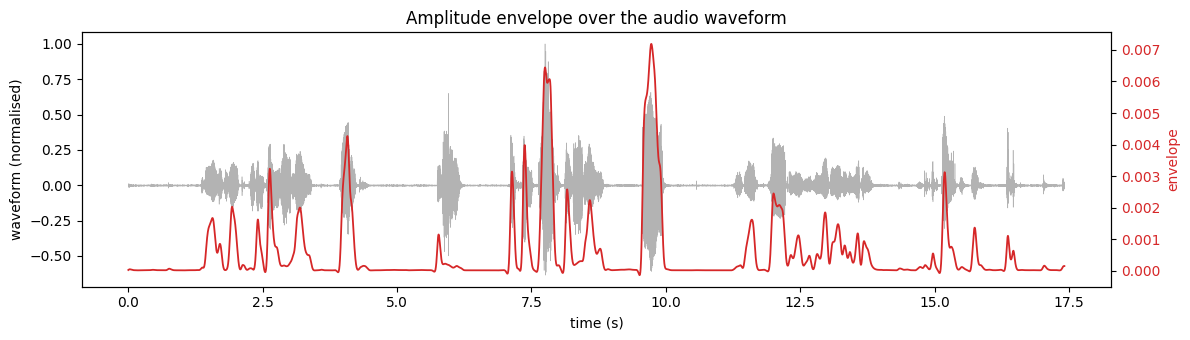

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t_wav, wav, color='0.7', lw=0.4)
ax.set_xlabel('time (s)'); ax.set_ylabel('waveform (normalised)')
ax2 = ax.twinx()
ax2.plot(t_env, envelope, color='C3', lw=1.3)
ax2.set_ylabel('envelope', color='C3'); ax2.tick_params(axis='y', labelcolor='C3')
ax.set_title('Amplitude envelope over the audio waveform')
plt.tight_layout()

## 2. Envelope change, then absolutized

The change is the frame-to-frame difference of the envelope (`np.diff`), which is
signed: positive where the envelope rises, negative where it falls. Taking
`np.abs` keeps only the magnitude of change.

(Your pipeline's `envelope_change` column is this `|change|` after an extra
low-pass smoothing and a multiply by the sample rate, so it has the same shape,
just smoothed and rescaled.)

change    : (8708,) | range -0.0001 to 0.0002
change_abs: (8708,) | range 0.0 to 0.0002


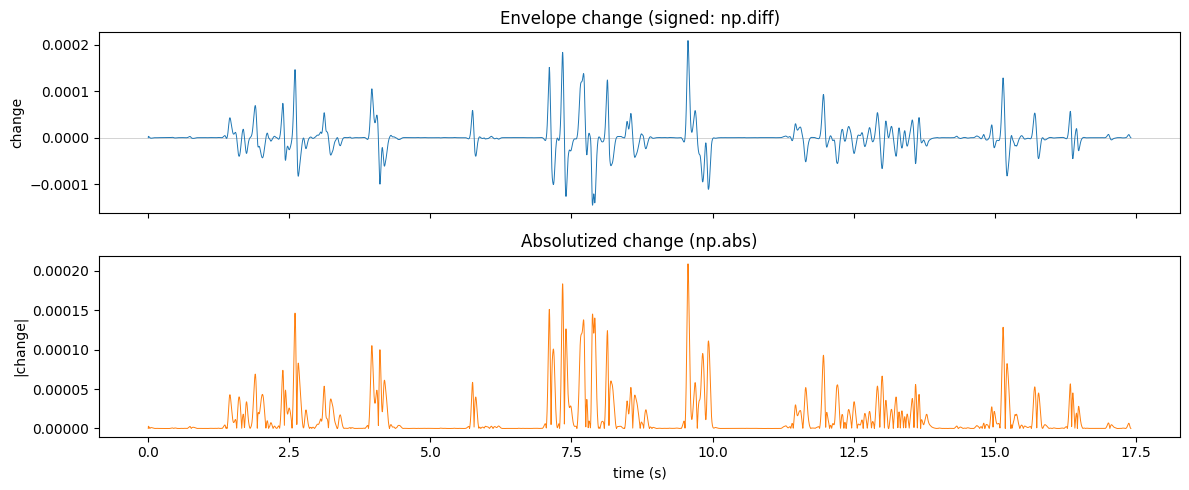

In [5]:
change     = np.insert(np.diff(envelope), 0, 0)   # prepend 0 to keep the same length
change_abs = np.abs(change)
print('change    :', change.shape, '| range', round(float(change.min()), 4), 'to', round(float(change.max()), 4))
print('change_abs:', change_abs.shape, '| range', round(float(change_abs.min()), 4), 'to', round(float(change_abs.max()), 4))

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].axhline(0, color='0.8', lw=0.6)
ax[0].plot(t_env, change, color='C0', lw=0.7)
ax[0].set_ylabel('change'); ax[0].set_title('Envelope change (signed: np.diff)')
ax[1].plot(t_env, change_abs, color='C1', lw=0.7)
ax[1].set_ylabel('|change|'); ax[1].set_xlabel('time (s)'); ax[1].set_title('Absolutized change (np.abs)')
plt.tight_layout()

## 3. IMF 1 and IMF 2 of the envelope

EMD splits the envelope into intrinsic mode functions, fastest first. IMF 1 is
the fast component, IMF 2 the slower one.

imf_env: ndarray | shape (8708, 2) (samples, imfs)


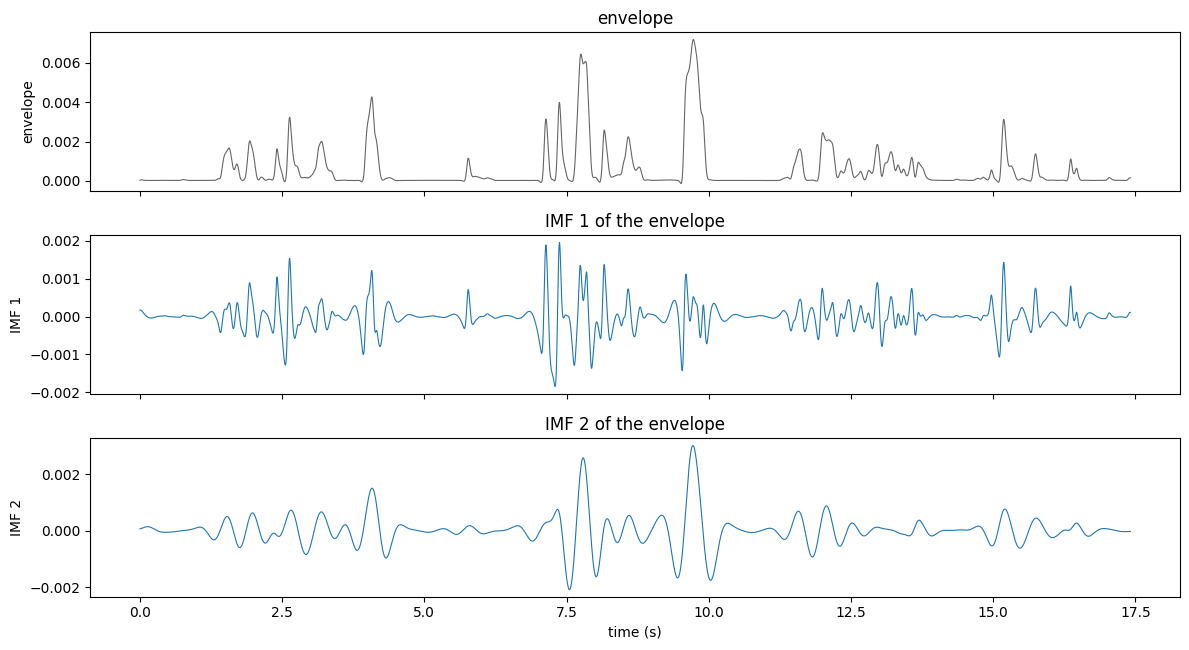

In [6]:
imf_env = emd.sift.mask_sift(envelope, max_imfs=2)
print('imf_env:', type(imf_env).__name__, '| shape', imf_env.shape, '(samples, imfs)')

n = min(2, imf_env.shape[1])
fig, ax = plt.subplots(n + 1, 1, figsize=(12, 2.2 * (n + 1)), sharex=True)
ax[0].plot(t_env, envelope, color='0.4', lw=0.8); ax[0].set_ylabel('envelope'); ax[0].set_title('envelope')
for k in range(n):
    ax[k + 1].plot(t_env, imf_env[:, k], color='C0', lw=0.8)
    ax[k + 1].set_ylabel(f'IMF {k + 1}'); ax[k + 1].set_title(f'IMF {k + 1} of the envelope')
ax[-1].set_xlabel('time (s)')
plt.tight_layout()

## 4. IMF 1 and IMF 2 of the envelope change

The same decomposition, run on the absolutized change instead of the envelope.

imf_change: ndarray | shape (8708, 2) (samples, imfs)


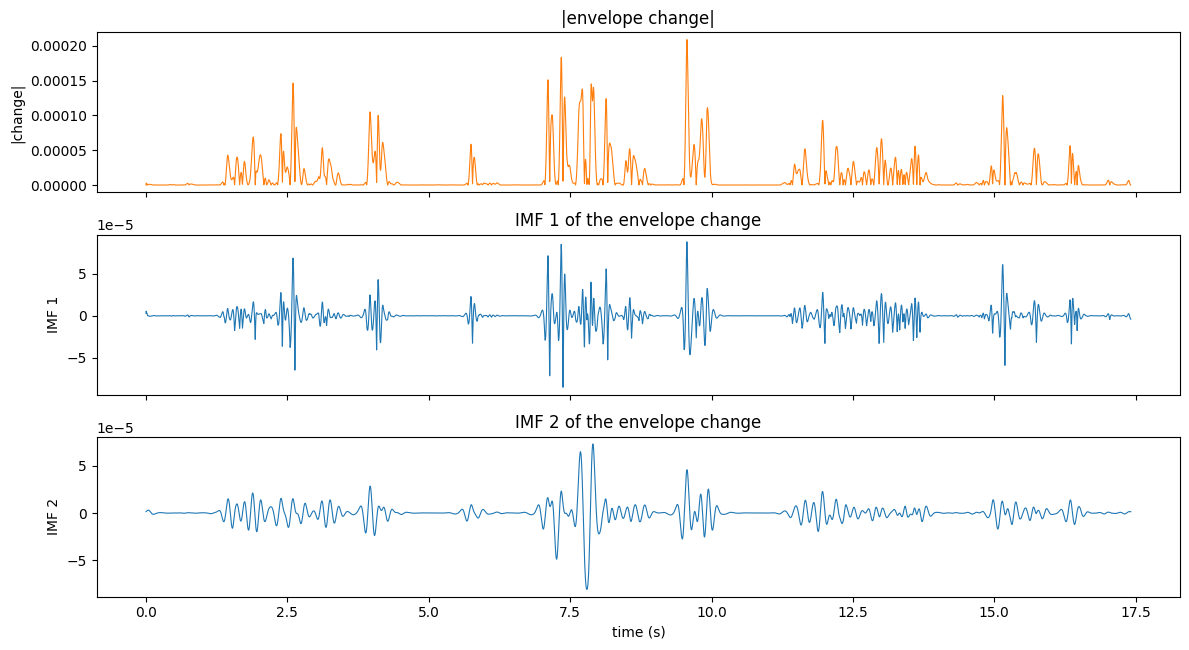

In [7]:
imf_change = emd.sift.mask_sift(change_abs, max_imfs=2)
print('imf_change:', type(imf_change).__name__, '| shape', imf_change.shape, '(samples, imfs)')

n = min(2, imf_change.shape[1])
fig, ax = plt.subplots(n + 1, 1, figsize=(12, 2.2 * (n + 1)), sharex=True)
ax[0].plot(t_env, change_abs, color='C1', lw=0.8); ax[0].set_ylabel('|change|'); ax[0].set_title('|envelope change|')
for k in range(n):
    ax[k + 1].plot(t_env, imf_change[:, k], color='C0', lw=0.8)
    ax[k + 1].set_ylabel(f'IMF {k + 1}'); ax[k + 1].set_title(f'IMF {k + 1} of the envelope change')
ax[-1].set_xlabel('time (s)')
plt.tight_layout()